In [11]:
# STEP 1: IMPORT LIBRARIES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For visualizations inside notebook
%matplotlib inline

# STEP 2: LOAD DATA
df = pd.read_csv("depression.csv")  # Change filename if needed
print("Shape of dataset:", df.shape)
df.head()


Shape of dataset: (38627, 41)


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
0,Jennifer Davis,theresa92@example.com,High school,Urban,Female,No,Small screen,Unique network,Right,Other,...,1,5,7,7,7,7,7,5,1,1
1,Jack Kelley,ehernandez@example.net,High school,Urban,Female,Yes,Big screen,Unique network,Left,Christian (Other),...,6,5,4,7,5,4,7,7,1,5
2,Trevor Rivera,bsmith@example.net,High school,Urban,Female,No,Big screen,Unique network,Right,Christian (Catholic),...,2,5,2,2,5,6,5,5,3,2
3,Erika Hopkins,buckdavid@example.org,Less than high school,Urban,Female,Yes,Big screen,Unique network,Left,Christian (Catholic),...,1,1,7,4,6,4,6,1,6,1
4,Charles Odom,simmonstammy@example.org,University degree,Suburban,Female,No,Big screen,Shared network,Both,Muslim,...,2,5,3,6,5,5,5,6,3,3


In [12]:
# STEP 3: BASIC STRUCTURE CHECKS
df.info()
df.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38627 entries, 0 to 38626
Data columns (total 41 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   full_name              38627 non-null  object
 1   email                  38627 non-null  object
 2   education              38136 non-null  object
 3   urban                  38256 non-null  object
 4   gender                 38561 non-null  object
 5   engnat                 38577 non-null  object
 6   screensize             38627 non-null  object
 7   uniquenetworklocation  38627 non-null  object
 8   hand                   38457 non-null  object
 9   religion               38283 non-null  object
 10  orientation            35567 non-null  object
 11  race                   38627 non-null  object
 12  voted                  38313 non-null  object
 13  married                38434 non-null  object
 14  familysize             38627 non-null  int64 
 15  age                

,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
count,38627,38627,38136,38256,38561,38577,38627,38627,38457,38283,...,38627.000000,38627.000000,38627.000000,38627.000000,38627.00000,38627.000000,38627.000000,38627.000000,38627.000000,38627.000000
unique,32291,36004,4,3,3,2,2,2,3,12,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Michael Brown,asmith@example.net,University degree,Urban,Female,No,Small screen,Unique network,Right,Muslim,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,21,7,14783,17368,29595,24917,28163,30821,33811,21786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,3.786626,4.187641,4.734926,5.175887,4.92803,4.851736,5.277940,4.286302,3.651539,3.749761
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.897188,1.821459,1.801859,1.821893,1.72157,1.902710,1.618689,1.966522,1.826227,1.859893
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,2.000000,3.000000,4.000000,4.000000,4.00000,4.000000,5.000000,3.000000,2.000000,2.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.000000,5.000000,5.000000,6.000000,5.00000,5.000000,6.000000,5.000000,4.000000,4.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.000000,6.000000,6.000000,7.000000,6.00000,6.000000,7.000000,6.000000,5.000000,5.000000


In [13]:
# STEP 4: CHECK MISSING VALUES
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
full_name                   0
email                       0
education                 491
urban                     371
gender                     66
engnat                     50
screensize                  0
uniquenetworklocation       0
hand                      170
religion                  344
orientation              3060
race                        0
voted                     314
married                   193
familysize                  0
age                         0
country                     2
Q3A                         0
Q5A                         0
Q10A                        0
Q13A                        0
Q16A                        0
Q17A                        0
Q21A                        0
Q24A                        0
Q26A                        0
Q31A                        0
Q34A                        0
Q37A                        0
Q38A                        0
Q42A                        0
TIPI1                       0
TIPI2       

In [14]:
# Drop rows where more than 30% of the columns are missing
threshold = int(0.3 * df.shape[1])
df = df[df.isnull().sum(axis=1) <= threshold]
categorical_cols = ['education', 'urban', 'gender', 'engnat', 'hand', 'religion',
                    'orientation', 'race', 'voted', 'married', 'country']
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(), inplace=True)

print("Remaining missing values:")
print(df.isnull().sum().sum())  


Remaining missing values:
0


C:\Users\diyab\AppData\Local\Temp\ipykernel_9028\1148242131.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
C:\Users\diyab\AppData\Local\Temp\ipykernel_9028\1148242131.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

In [15]:
# STEP 5: CHECK DUPLICATES
num_duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {num_duplicates}")

# If you want to remove duplicates:
# df = df.drop_duplicates()


Number of duplicate rows: 0


In [16]:
# STEP 6: VALUE SANITY CHECKS for Depression Dataset

# Invalid age: outside reasonable human range (say <12 or >120)
invalid_age = df[(df['age'] < 10) | (df['age'] > 120)]

# Gender sanity check
valid_genders = ['Male', 'Female', 'Other']
invalid_gender = df[~df['gender'].isin(valid_genders)]

# Urban field sanity (should be: Urban, Suburban, Rural or similar)
valid_urban = ['Urban', 'Suburban', 'Rural']
invalid_urban = df[~df['urban'].isin(valid_urban)]

# Handedness (hand column)
valid_hands = ['Left', 'Right', 'Both']
invalid_hand = df[~df['hand'].isin(valid_hands)]

# Religion - we won’t validate exact values (subjective), but can log unique values
unique_religions = df['religion'].unique()

# Orientation - just log unique values
unique_orientation = df['orientation'].unique()

# Country sanity check (optional)
invalid_country = df[df['country'].str.len() != 2]  # country codes should be 2 letters (like US, IN, GB)

# Print summaries
print(f"Invalid age entries: {len(invalid_age)}")
display(invalid_age)

print(f"\n Invalid gender entries: {len(invalid_gender)}")
display(invalid_gender)

print(f"\n Invalid urban entries: {len(invalid_urban)}")
display(invalid_urban)

print(f"\n Invalid hand entries: {len(invalid_hand)}")
display(invalid_hand)

print(f"\n Unique religions: {unique_religions}")
print(f" Unique orientations: {unique_orientation}")

print(f"\n Invalid country codes: {len(invalid_country)}")
display(invalid_country)


Invalid age entries: 5


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
5113,Julie Frazier,vegadavid@example.net,University degree,Rural,Female,No,Small screen,Shared network,Right,Muslim,...,7,3,6,3,6,2,1,2,6,2
9919,Michele White,pittmanjohn@example.com,High school,Urban,Female,No,Big screen,Unique network,Right,Muslim,...,5,5,7,7,5,7,5,3,5,7
20727,Martin Baker,robert83@example.org,University degree,Urban,Female,No,Small screen,Unique network,Right,Muslim,...,0,0,0,6,0,7,0,0,0,0
29151,Diana Holt,davidgomez@example.org,University degree,Rural,Female,No,Small screen,Unique network,Right,Muslim,...,4,6,7,7,6,7,7,6,2,6
32767,Alexandra Kelly,sgarza@example.org,University degree,Suburban,Male,No,Small screen,Shared network,Right,Atheist,...,2,6,7,7,4,5,6,6,2,6



 Invalid gender entries: 0


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10



 Invalid urban entries: 0


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10



 Invalid hand entries: 0


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10



 Unique religions: ['Other' 'Christian (Other)' 'Christian (Catholic)' 'Muslim' 'Atheist'
 'Christian (Protestant)' 'Agnostic' 'Hindu' 'Buddhist'
 'Christian (Mormon)' 'Sikh' 'Jewish']
 Unique orientations: ['Heterosexual' 'Homosexual' 'Other' 'Bisexual' 'Asexual']

 Invalid country codes: 516


,full_name,email,education,urban,gender,engnat,screensize,uniquenetworklocation,hand,religion,...,TIPI1,TIPI2,TIPI3,TIPI4,TIPI5,TIPI6,TIPI7,TIPI8,TIPI9,TIPI10
37,Aaron Ayers,carlos32@example.net,High school,Urban,Male,No,Small screen,Unique network,Left,Christian (Other),...,5,6,6,2,7,4,3,5,5,2
201,Erica Gross,ramirezmelissa@example.org,Graduate degree,Rural,Male,Yes,Big screen,Unique network,Right,Christian (Catholic),...,5,5,5,5,5,5,5,3,3,3
215,Jennifer Wheeler,rileydaniel@example.net,University degree,Suburban,Female,No,Big screen,Unique network,Both,Christian (Other),...,2,5,3,4,2,4,2,1,3,3
305,Dylan Roberts,robertbrown@example.com,High school,Suburban,Male,Yes,Big screen,Unique network,Right,Other,...,5,2,6,2,6,5,5,2,7,2
394,Debra Cannon,martinezkatie@example.com,High school,Rural,Female,Yes,Big screen,Unique network,Right,Agnostic,...,1,6,4,6,3,7,3,4,4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
38358,Brad Arnold,jeanettetaylor@example.net,University degree,Urban,Female,No,Small screen,Shared network,Right,Muslim,...,3,4,6,7,2,4,7,1,2,5
38415,Jeffrey Smith,laurendavis@example.net,University degree,Urban,Female,No,Small screen,Unique network,Right,Christian (Catholic),...,6,2,7,6,6,6,6,5,6,4
38469,Christy Davis,carmen43@example.org,Less than high school,Urban,Male,No,Big screen,Unique network,Right,Atheist,...,2,5,5,0,4,5,2,6,0,5
38475,Maria Martinez,rodriguezcrystal@example.org,University degree,Urban,Male,Yes,Big screen,Unique network,Right,Christian (Protestant),...,5,3,3,4,5,2,7,5,4,1


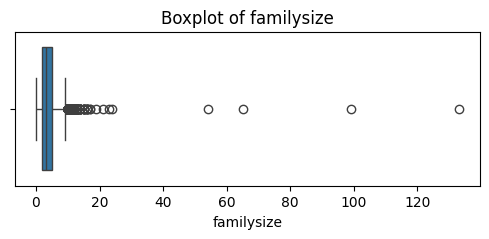


Top outliers in 'familysize':
33902    133
16307     99
19147     65
17650     54
28929     24
Name: familysize, dtype: int64


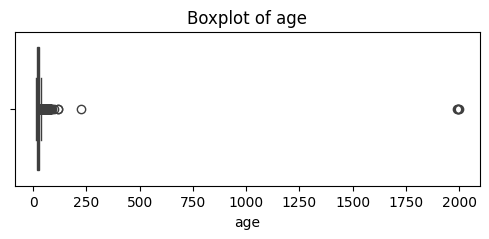


Top outliers in 'age':
20727    1998
9919     1996
29151    1993
32767    1991
5113      223
Name: age, dtype: int64


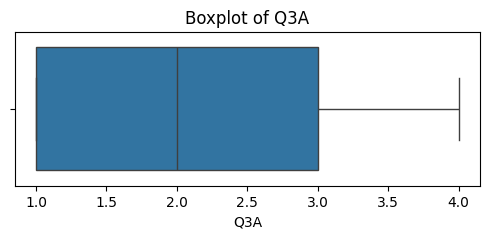


Top outliers in 'Q3A':
2        4
38607    4
13675    4
13676    4
13677    4
Name: Q3A, dtype: int64


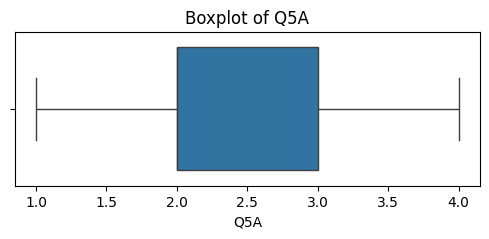


Top outliers in 'Q5A':
38596    4
38595    4
38626    4
0        4
1        4
Name: Q5A, dtype: int64


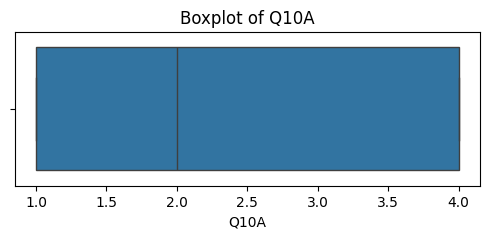


Top outliers in 'Q10A':
2        4
6        4
9        4
17562    4
17565    4
Name: Q10A, dtype: int64


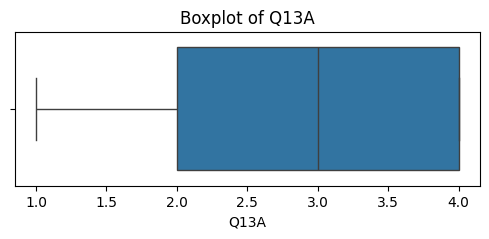


Top outliers in 'Q13A':
38625    4
0        4
38609    4
38608    4
38607    4
Name: Q13A, dtype: int64


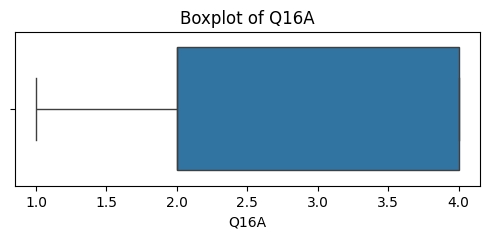


Top outliers in 'Q16A':
5        4
38626    4
0        4
18471    4
18474    4
Name: Q16A, dtype: int64


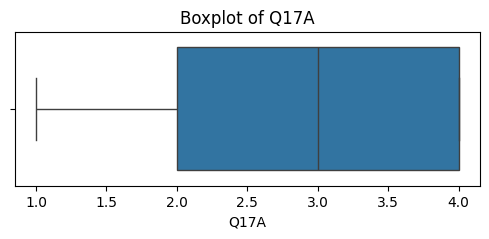


Top outliers in 'Q17A':
38626    4
38608    4
38606    4
38605    4
38602    4
Name: Q17A, dtype: int64


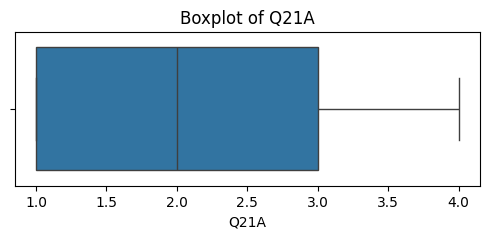


Top outliers in 'Q21A':
2        4
38626    4
38608    4
6        4
9        4
Name: Q21A, dtype: int64


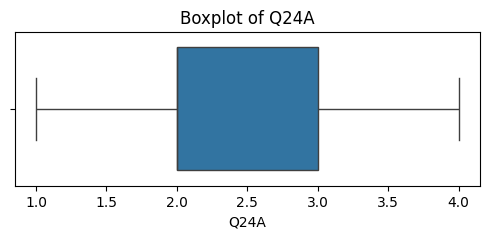


Top outliers in 'Q24A':
38604    4
38597    4
38595    4
38593    4
38592    4
Name: Q24A, dtype: int64


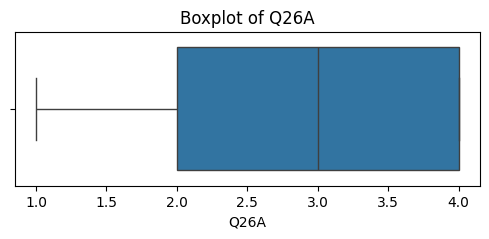


Top outliers in 'Q26A':
4        4
8        4
0        4
9        4
38610    4
Name: Q26A, dtype: int64


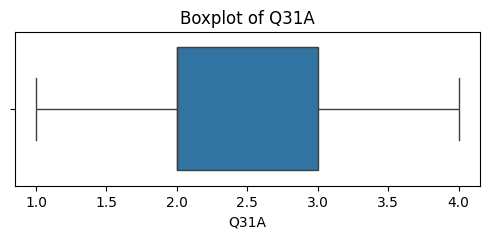


Top outliers in 'Q31A':
38603    4
38601    4
38596    4
38595    4
38592    4
Name: Q31A, dtype: int64


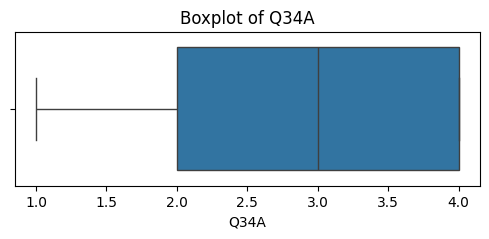


Top outliers in 'Q34A':
2        4
3        4
4        4
20181    4
20189    4
Name: Q34A, dtype: int64


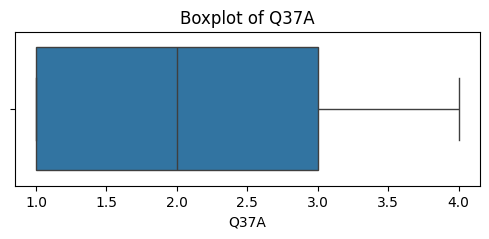


Top outliers in 'Q37A':
38607    4
38603    4
38602    4
38601    4
38598    4
Name: Q37A, dtype: int64


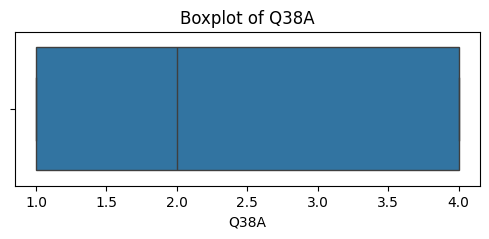


Top outliers in 'Q38A':
2        4
38626    4
6        4
16864    4
16882    4
Name: Q38A, dtype: int64


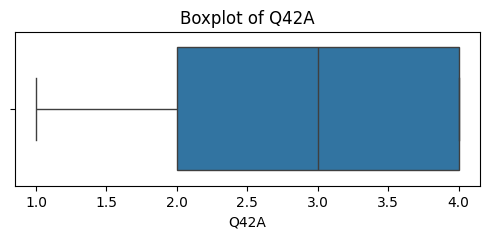


Top outliers in 'Q42A':
23       4
38626    4
25       4
27       4
38619    4
Name: Q42A, dtype: int64


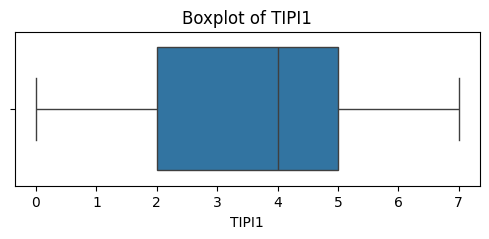


Top outliers in 'TIPI1':
26       7
16435    7
27339    7
27328    7
27317    7
Name: TIPI1, dtype: int64


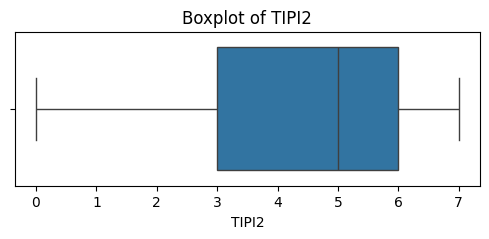


Top outliers in 'TIPI2':
18       7
31       7
38597    7
10005    7
20057    7
Name: TIPI2, dtype: int64


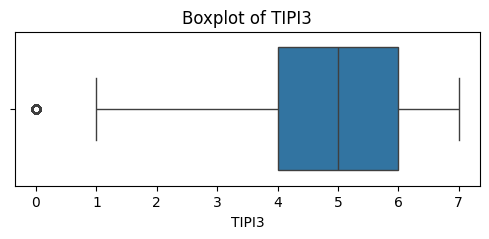


Top outliers in 'TIPI3':
38       7
0        7
3        7
43       7
38624    7
Name: TIPI3, dtype: int64


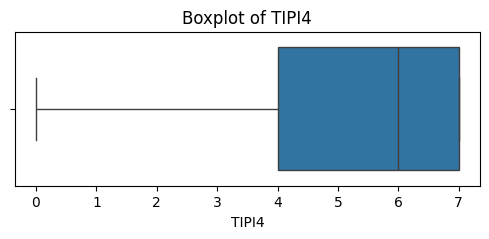


Top outliers in 'TIPI4':
38604    7
38620    7
38619    7
38618    7
16       7
Name: TIPI4, dtype: int64


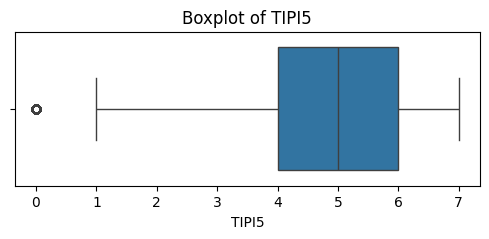


Top outliers in 'TIPI5':
38593    7
26       7
25       7
17       7
38578    7
Name: TIPI5, dtype: int64


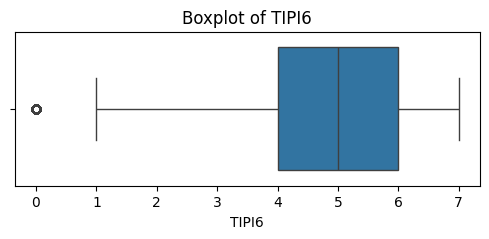


Top outliers in 'TIPI6':
0        7
38606    7
5        7
8        7
17238    7
Name: TIPI6, dtype: int64


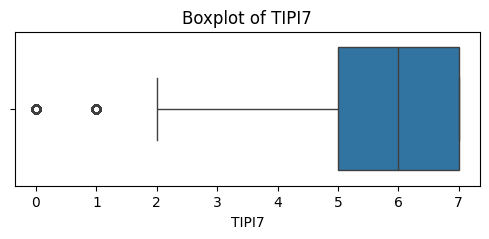


Top outliers in 'TIPI7':
1        7
20409    7
20416    7
20420    7
20422    7
Name: TIPI7, dtype: int64


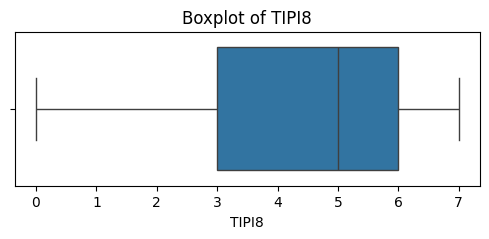


Top outliers in 'TIPI8':
17698    7
24445    7
16595    7
22738    7
11894    7
Name: TIPI8, dtype: int64


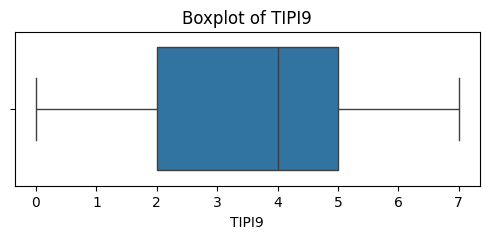


Top outliers in 'TIPI9':
38574    7
24424    7
24397    7
24392    7
7312     7
Name: TIPI9, dtype: int64


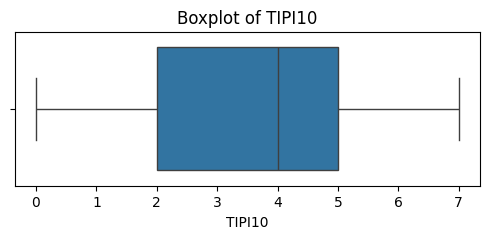


Top outliers in 'TIPI10':
38617    7
32240    7
32250    7
13974    7
32242    7
Name: TIPI10, dtype: int64


In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# STEP 7: CHECK OUTLIERS (NUMERIC)

# Identify numeric columns (excluding identifiers or scores that shouldn't be clipped)
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    plt.figure(figsize=(6, 2))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()
    
    # Optional: Print top extreme values
    print(f"\nTop outliers in '{col}':")
    print(df[col].sort_values(ascending=False).head())



In [18]:
# STEP 8: HIGH CARDINALITY CHECK

# Select categorical columns from current dataset
cat_cols = ['education', 'urban', 'gender', 'engnat', 'hand', 
            'religion', 'orientation', 'race', 'voted', 'married', 'country']

for col in cat_cols:
    if col in df.columns:
        print(f"\n Unique values in '{col}': {df[col].nunique()}")
        print(df[col].value_counts().head())



 Unique values in 'education': 4
education
University degree        15274
High school              14604
Graduate degree           4890
Less than high school     3859
Name: count, dtype: int64

 Unique values in 'urban': 3
urban
Urban       17739
Suburban    12812
Rural        8076
Name: count, dtype: int64

 Unique values in 'gender': 3
gender
Female    29661
Male       8444
Other       522
Name: count, dtype: int64

 Unique values in 'engnat': 2
engnat
No     24967
Yes    13660
Name: count, dtype: int64

 Unique values in 'hand': 3
hand
Right    33981
Left      4060
Both       586
Name: count, dtype: int64

 Unique values in 'religion': 12
religion
Muslim                  22130
Atheist                  3637
Agnostic                 3052
Christian (Catholic)     2996
Christian (Other)        2131
Name: count, dtype: int64

 Unique values in 'orientation': 5
orientation
Heterosexual    26691
Bisexual         4775
Other            3370
Asexual          1921
Homosexual       1870
Name: 

In [19]:
# STEP 9: REMOVE INVALID AGE ENTRIES AND SAVE CLEANED FILE

# Keep rows with valid human age range (e.g., 5–120)
df_cleaned = df[(df['age'] >= 10) & (df['age'] <= 120)].copy()

# Sanity check
print(f" Number of invalid age entries removed: {(df['age'] < 5).sum() + (df['age'] > 120).sum()}")

# Save to Excel
df_cleaned.to_excel("cleaned_depression_data.xlsx", index=False)


 Number of invalid age entries removed: 5


In [20]:
import numpy as np

# STEP 9: SPLIT INTO 3 HOSPITALS (RANDOM SPLIT)

# Shuffle and reset index for randomness
df_shuffled = df_cleaned.sample(frac=1, random_state=42).reset_index(drop=True)

# Split into 3 roughly equal parts
splits = np.array_split(df_shuffled, 3)

# Save each split as a separate CSV file
for i, subset in enumerate(splits):
    subset.to_csv(f"hospital_{i+1}.csv", index=False)
    print(f" Saved {len(subset)} rows to hospital_{i+1}.csv")


C:\Users\diyab\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


 Saved 12874 rows to hospital_1.csv
 Saved 12874 rows to hospital_2.csv
 Saved 12874 rows to hospital_3.csv
